In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import chardet
import matplotlib
import numpy as np
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
# 设置 Matplotlib 支持中文的字体
matplotlib.rcParams['font.sans-serif'] = ['SimHei']  # 'SimHei' 是一种常用的中文字体
matplotlib.rcParams['font.family']='sans-serif'
matplotlib.rcParams['axes.unicode_minus'] = False  # 正确显示负号


In [30]:

df = pd.read_csv('transport_data.csv',encoding='GB2312')
df = df.fillna(0)
# 显示前几行数据以确认读取正确
print(df.head())

    价格   购买人数   包邮  运费险   新品  公益宝贝  全球购
0   69  20000  1.0  0.0  0.0   0.0  0.0
1   79  20000  1.0  0.0  0.0   1.0  0.0
2   78  10000  0.0  0.0  0.0   0.0  0.0
3  414  10000  0.0  0.0  0.0   0.0  0.0
4  149  10000  0.0  0.0  0.0   0.0  0.0


In [31]:
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
# 4. 多变量关联分析
# 使用多元线性回归模型分析
X = df[[ '运费险', '全球购']]  # 独立变量
y = df['购买人数']  # 因变量
X = sm.add_constant(X)  # 添加常数项
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                   购买人数   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     3.268
Date:                Fri, 01 Dec 2023   Prob (F-statistic):             0.0383
Time:                        21:19:22   Log-Likelihood:                -14503.
No. Observations:                1717   AIC:                         2.901e+04
Df Residuals:                    1714   BIC:                         2.903e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        426.9197     43.881      9.729      0.0

In [32]:
from sklearn.ensemble import RandomForestRegressor

# 对响应变量进行对数变换
df['购买人数_log'] = np.log1p(df['购买人数'])

# 使用随机森林作为非参数回归模型
X = df[[ '运费险',  '全球购']]  # 独立变量
y = df['购买人数_log']  # 对数变换后的因变量

# 拟合随机森林模型
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# 输出特征的重要性
importance = rf.feature_importances_
print("Feature importances:", importance)

# 如果需要对未变换的购买人数进行预测，需要将结果变换回原始尺度
y_pred_log = rf.predict(X)
y_pred = np.expm1(y_pred_log)  # 使用 expm1 对数变换的逆变换


Feature importances: [0.46099296 0.53900704]


CV RMSE scores: [2.31663909 0.50256267 0.52740052 0.76755739 1.21744576]
CV RMSE mean: 1.066321082908989
Train RMSE: 1.0340220471811916


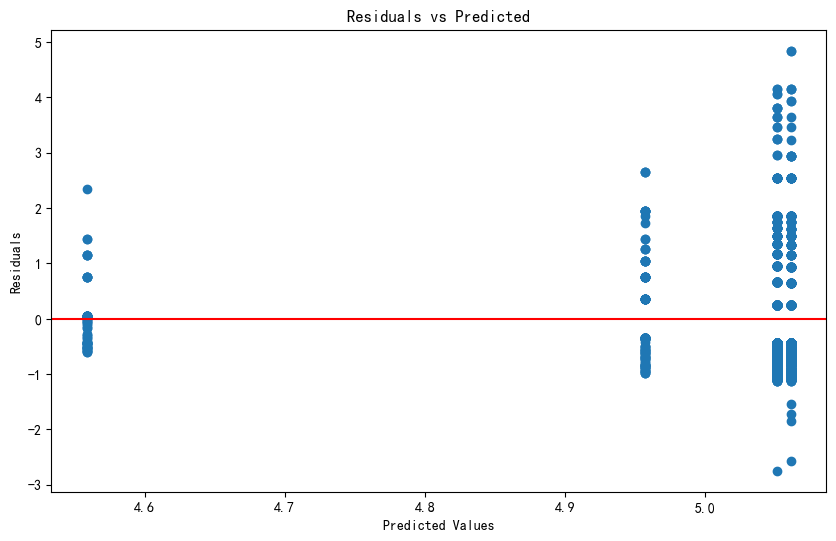

In [13]:
from sklearn.model_selection import cross_val_score

# 使用交叉验证来评估模型性能
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='neg_mean_squared_error')
cv_rmse = np.sqrt(-cv_scores)
print("CV RMSE scores:", cv_rmse)
print("CV RMSE mean:", cv_rmse.mean())

from sklearn.metrics import mean_squared_error

# 计算训练集上的预测值
train_predictions = rf.predict(X)

# 计算 RMSE
train_mse = mean_squared_error(y, train_predictions)
train_rmse = np.sqrt(train_mse)
print("Train RMSE:", train_rmse)
residuals = y - train_predictions

plt.figure(figsize=(10, 6))
plt.scatter(train_predictions, residuals)
plt.title('Residuals vs Predicted')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.axhline(y=0, color='r', linestyle='-')
plt.show()


# 评分因素分析

In [38]:
with open('transport_data.csv', 'rb') as file:
    print(chardet.detect(file.read()))
df = pd.read_csv('shop.csv', encoding='gbk')  # 尝试gbk编码


df.isnull().sum()
df.dropna(inplace=True)


{'encoding': 'GB2312', 'confidence': 0.99, 'language': 'Chinese'}


In [14]:
df.describe()

,宝贝描述,卖家服务,物流服务,购买人数
count,645.000000,645.000000,645.000000,645.000000
mean,4.808992,4.828217,4.835504,819.854264
std,0.070357,0.058798,0.061008,3322.060222
min,4.500000,4.600000,4.600000,15.000000
25%,4.800000,4.800000,4.800000,74.000000
50%,4.800000,4.800000,4.800000,100.000000
75%,4.900000,4.900000,4.900000,400.000000
max,5.000000,5.000000,5.000000,70000.000000


In [35]:
import pandas as pd

# 假设df是包含评分数据的DataFrame
# 例如：
# df = pd.read_csv('your_file.csv')

# 定义一个简单的函数，将评分转换为等级
def rating_to_grade(rating):
    if rating == 4.5:
        return 1
    elif rating == 4.6:
        return 1
    elif rating == 4.7:
        return 3
    elif rating == 4.8:
        return 7
    elif rating == 4.9:
        return 10
    elif rating == 5.0:
        return 20
    # 根据需要添加更多的条件
    else:
        return 0  # 或者其他代表缺失或无效评分的代码

# 应用转换函数到每一行的评分数据
df['宝贝描述等级'] = df['宝贝描述'].apply(rating_to_grade)
df['卖家服务等级'] = df['卖家服务'].apply(rating_to_grade)
df['物流服务等级'] = df['物流服务'].apply(rating_to_grade)

# 查看转换后的数据
print(df[['宝贝描述等级', '卖家服务等级', '物流服务等级']])


     宝贝描述等级  卖家服务等级  物流服务等级
0         7       7       7
1         7       7       7
2         7       7       7
3         7       7       7
4         7       7       7
..      ...     ...     ...
640      20      20      20
641       7       7       7
642      10      10      10
643      10      10      10
644      10      10      10

[645 rows x 3 columns]


In [36]:
from sklearn.ensemble import RandomForestRegressor

# 对响应变量进行对数变换
df['购买人数_log'] = np.log1p(df['购买人数'])

# 使用随机森林作为非参数回归模型
X = df[[ '宝贝描述等级', '卖家服务等级', '物流服务等级']]  # 独立变量
y = df['购买人数_log']  # 对数变换后的因变量

# 拟合随机森林模型
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# 输出特征的重要性
importance = rf.feature_importances_
print("Feature importances:", importance)

# 如果需要对未变换的购买人数进行预测，需要将结果变换回原始尺度
y_pred_log = rf.predict(X)
y_pred = np.expm1(y_pred_log)  # 使用 expm1 对数变换的逆变换


Feature importances: [0.45596509 0.32262121 0.2214137 ]


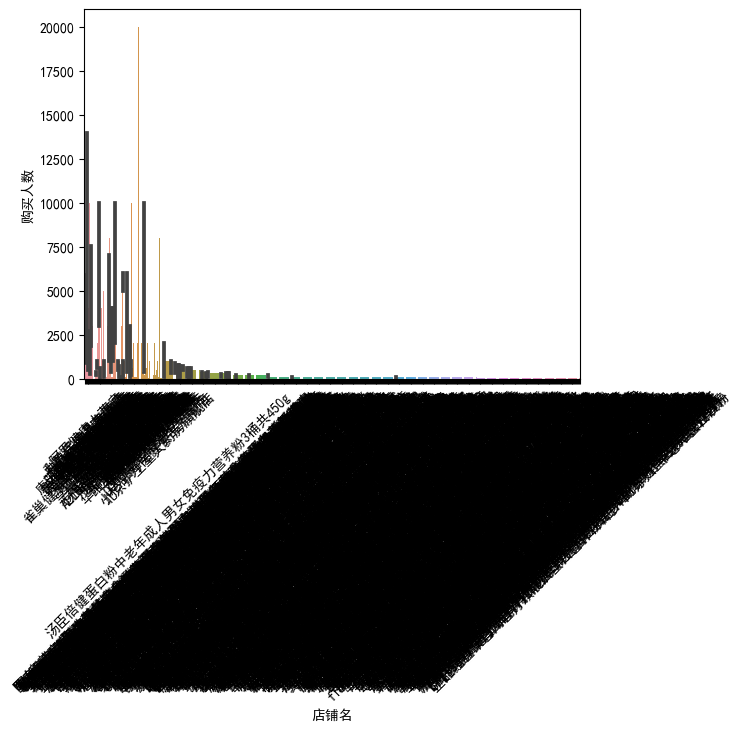

In [16]:
sns.barplot(x='店铺名', y='购买人数', data=df)
plt.xticks(rotation=45)
plt.show()


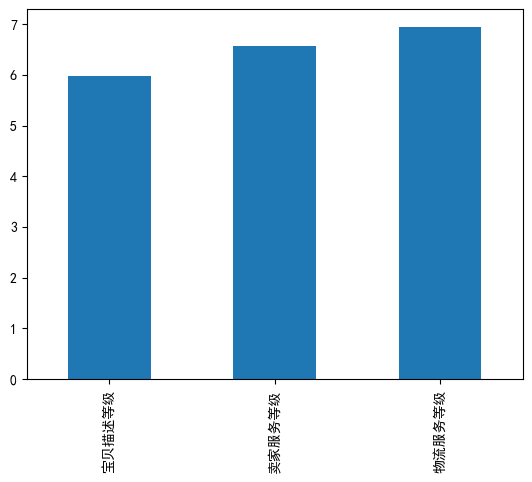

In [25]:
df[['宝贝描述等级', '卖家服务等级', '物流服务等级']].mean().plot(kind='bar')
plt.show()



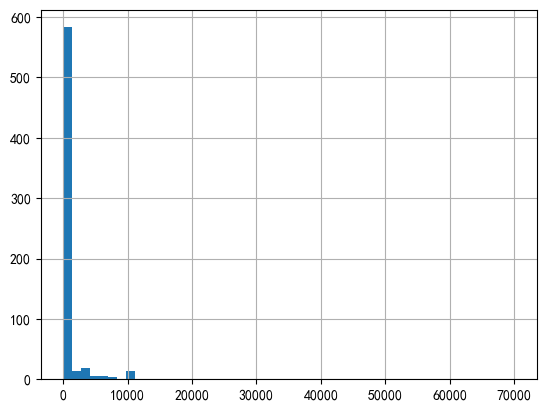

In [22]:
df['购买人数'].hist(bins=50)
plt.show()


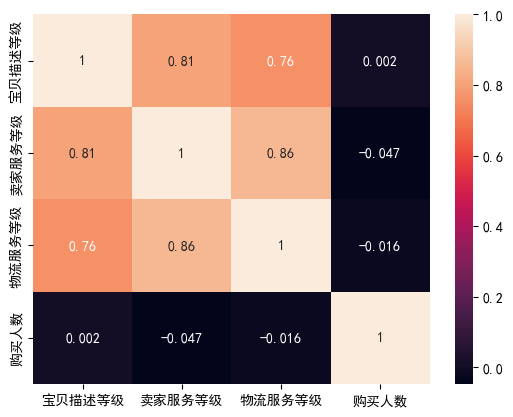

In [28]:
sns.heatmap(df[['宝贝描述等级', '卖家服务等级', '物流服务等级', '购买人数']].corr(), annot=True)
plt.show()
